# Preprocesamiento de Datos
Osvaldo Ceballos O.

### (Paréntesis de información)...

In [ ]:
import math

def shannon_entropy_dice(sides):
    # Probabilidad de cada lado del dado (asumiendo que es un dado justo)
    probability = 1 / sides

    # Calcula la entropía para cada lado del dado
    entropy = -sides * (probability * math.log2(probability))

    return entropy


In [1]:
# Ejemplo de uso con un dado de 6 caras:
sides = 6 #@param
entropy = shannon_entropy_dice(sides)
print(f"La entropía de Shannon para un dado de {sides} caras es: {entropy}")

NameError: name 'shannon_entropy_dice' is not defined

Ahora un poquito mas pro

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from scipy.stats import entropy

def calculate_entropy(column):
    # Contar las frecuencias de cada valor en la columna
    value_counts = column.value_counts(normalize=True)

    # Calcular la entropía utilizando la fórmula de Shannon
    return entropy(value_counts, base=2)


In [ ]:
# Cargar el dataset Iris
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

np.random.seed(42)  # Fijar la semilla
iris_df['data_rnd'] = np.random.uniform(0, 1, size=len(iris_df)) # Variable aleatoria entre 0 y 1
iris_df['data_0'] = 0 #variable constante en valor 0
iris_df['data_id'] = np.arange(1, len(iris_df) + 1) #Correlativo

# Calcular la entropía para cada variable
entropies = iris_df.apply(calculate_entropy)
print(entropies)

sepal length (cm)    4.822018
sepal width (cm)     4.023181
petal length (cm)    5.034570
petal width (cm)     4.049827
species              1.584963
data_rnd             7.228819
data_0               0.000000
data_id              7.228819
dtype: float64


(150, 8)

## 1.- Missing Values

### 1.1 Missing Completely at Random (MCAR)

In [ ]:
import pandas as pd
import numpy as np

# Cargar el dataset mtcars
url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
cars_df = pd.read_csv(url)

# Introducir datos faltantes de manera completamente aleatoria en la columna 'mpg'
np.random.seed(42)
missing_mask = np.random.rand(len(cars_df)) < 0.1  # 10% de los datos serán faltantes
cars_df.loc[missing_mask, 'mpg'] = np.nan

# Mostrar el dataset con valores faltantes
cars_df.head(10)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast,cars,carname
0,4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4,1,Mazda RX4,Mazda RX4
1,4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4,1,Mazda RX4 Wag,Mazda RX4 Wag
2,4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1,1,Datsun 710,Datsun 710
3,4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1,1,Hornet 4 Drive,Hornet 4 Drive
4,4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2,1,Hornet Sportabout,Hornet Sportabout
5,4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1,1,Valiant,Valiant
6,NaN,8,360.0,245,3.21,3.570,15.84,0,0,3,4,0,Duster 360,Duster 360
7,4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2,1,Merc 240D,Merc 240D
8,4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2,1,Merc 230,Merc 230
9,4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4,1,Merc 280,Merc 280


<Axes: >

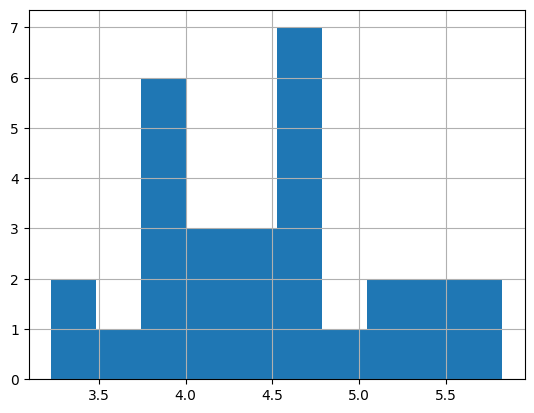

In [ ]:
cars_df['mpg'].hist()

<Axes: >

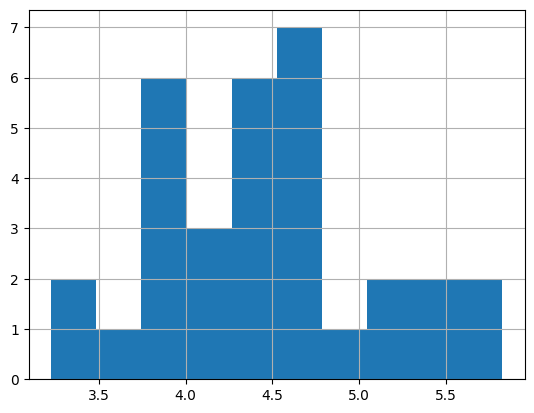

In [ ]:
cars_df['mpg'] = cars_df['mpg'].fillna(cars_df['mpg'].mean()) # Imputación por la media
cars_df['mpg'].hist()

### 1.2 Missing at Random (MAR)

In [ ]:
#utilizando el mismo dataset

# Introducir datos faltantes de manera aleatoria en la columna 'cyl'  para los cilindros mayores a 6
missing_mask = (cars_df['cyl'] > 6) &  (np.random.rand(len(cars_df)) < 0.3)  # 30% de los datos serán faltantes para los casos con cyl
cars_df.loc[missing_mask, 'disp'] = np.nan #lo aplicamos a la cilindrada
# Mostrar el dataset con valores faltantes
cars_df.head(50)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast,cars,carname
0,4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4,1,Mazda RX4,Mazda RX4
1,4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4,1,Mazda RX4 Wag,Mazda RX4 Wag
2,4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1,1,Datsun 710,Datsun 710
3,4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1,1,Hornet 4 Drive,Hornet 4 Drive
4,4.324350,8,NaN,175,3.15,3.440,17.02,0,0,3,2,1,Hornet Sportabout,Hornet Sportabout
5,4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1,1,Valiant,Valiant
6,NaN,8,360.0,245,3.21,3.570,15.84,0,0,3,4,0,Duster 360,Duster 360
7,4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2,1,Merc 240D,Merc 240D
8,4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2,1,Merc 230,Merc 230
9,4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4,1,Merc 280,Merc 280


In [ ]:
from sklearn.impute import KNNImputer
# Imputar datos faltantes usando KNN
# Crear un imputador KNN
imputer = KNNImputer(n_neighbors=5)  # Puedes ajustar el número de vecinos según sea necesario

# Imputar los datos faltantes usando todas las columnas disponibles (excepto 'disp')
features = cars_df[['cyl','hp','vs','am','gear','carb','fast','disp']]  # Excluimos 'disp' porque es la columna que queremos imputar
imputed_data = imputer.fit_transform(features)

# Crear un DataFrame con los datos imputados y la columna 'disp' imputada
imputed_df = pd.DataFrame(imputed_data, columns=features.columns)
imputed_df['disp_ant'] = cars_df['disp']  # A
imputed_df.head(50)

,cyl,hp,vs,am,gear,carb,fast,disp,disp_ant
0,6.0,110.0,0.0,1.0,4.0,4.0,1.0,160.00,160.0
1,6.0,110.0,0.0,1.0,4.0,4.0,1.0,160.00,160.0
2,4.0,93.0,1.0,1.0,4.0,1.0,1.0,108.00,108.0
3,6.0,110.0,1.0,0.0,3.0,1.0,1.0,258.00,258.0
4,8.0,175.0,0.0,0.0,3.0,2.0,1.0,302.96,NaN
5,6.0,105.0,1.0,0.0,3.0,1.0,1.0,225.00,225.0
6,8.0,245.0,0.0,0.0,3.0,4.0,0.0,360.00,360.0
7,4.0,62.0,1.0,0.0,4.0,2.0,1.0,146.70,146.7
8,4.0,95.0,1.0,0.0,4.0,2.0,1.0,140.80,140.8
9,6.0,123.0,1.0,0.0,4.0,4.0,1.0,167.60,167.6


### 1.3 Missing Not at Random (MNAR)

In [ ]:
# Cargar el dataset mtcars
url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
cars_df = pd.read_csv(url)

## Borrar columna carname por motivo del ejemplo
cars_df.drop(['cars'],axis=1,inplace= True)

# Establecer como nulos todas las columnas para los vehículos que contienen 'Mazda' en 'car_name'
cars_df.loc[cars_df['carname'].str.contains('Mazda'), cars_df.columns == 'carname'] = np.nan

cars_df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast,carname
0,4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4,1,NaN
1,4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4,1,NaN
2,4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1,1,Datsun 710
3,4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1,1,Hornet 4 Drive
4,4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2,1,Hornet Sportabout


In [ ]:
cars_df[cars_df['carname'].isna()].describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast
count,2.000000,2.0,2.0,2.0,2.0,2.000000,2.00000,2.0,2.0,2.0,2.0,2.0
mean,4.582576,6.0,160.0,110.0,3.9,2.747500,16.74000,0.0,1.0,4.0,4.0,1.0
std,0.000000,0.0,0.0,0.0,0.0,0.180312,0.39598,0.0,0.0,0.0,0.0,0.0
min,4.582576,6.0,160.0,110.0,3.9,2.620000,16.46000,0.0,1.0,4.0,4.0,1.0
25%,4.582576,6.0,160.0,110.0,3.9,2.683750,16.60000,0.0,1.0,4.0,4.0,1.0
50%,4.582576,6.0,160.0,110.0,3.9,2.747500,16.74000,0.0,1.0,4.0,4.0,1.0
75%,4.582576,6.0,160.0,110.0,3.9,2.811250,16.88000,0.0,1.0,4.0,4.0,1.0
max,4.582576,6.0,160.0,110.0,3.9,2.875000,17.02000,0.0,1.0,4.0,4.0,1.0


In [ ]:
cars_df = cars_df.dropna()

## 2.- Datos Incorrectos

### 2.1 Datos Fuera de Rango (OOR)

<Axes: >

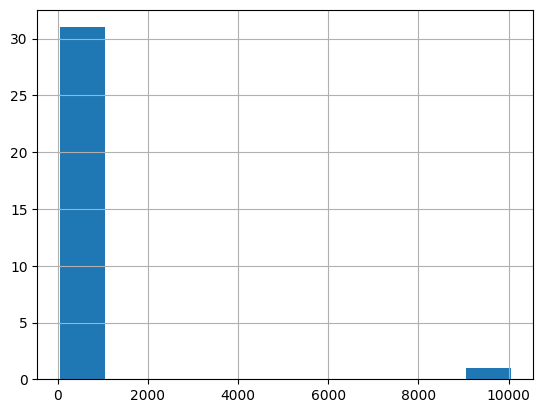

In [ ]:
# Cargar el dataset mtcars
url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
cars_df = pd.read_csv(url)

# cometeremos un error de data entry con vehículos que contienen 'Valiant' en 'car_name'
cars_df.loc[cars_df['carname'].str.contains('Valiant'), cars_df.columns == 'hp'] = 10050

cars_df['hp'].hist()

In [ ]:
cars_df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000,32.000000
mean,4.434770,6.187500,230.721875,457.468750,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125,0.687500
std,0.661137,1.785922,123.938694,1751.762872,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152,0.470929
min,3.224903,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000,0.000000
25%,3.927432,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000,0.000000
50%,4.381780,6.000000,196.300000,136.500000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000,1.000000
75%,4.774935,8.000000,326.000000,186.250000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000,1.000000
max,5.822371,8.000000,472.000000,10050.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000,1.000000


..... Siga ud

### 2.2.- Data Ruidosa

In [6]:
!pip install pydub ffmpeg-python

In [5]:
import numpy as np
import pandas as pd

In [29]:
from pydub import AudioSegment
from pydub.generators import Sine
from IPython.display import Audio, display

# Frecuencias de las notas para el acorde de La menor (A minor)
frequencies = {
    'A': 440,    # La (A4)
    'C': 523.25, # Do (C5)
    'E': 659.25  # Mi (E5)
}

# Duración de cada nota (en milisegundos)
duration = 3000  # 1 segundo

# Crear las notas
A_note = Sine(frequencies['A']).to_audio_segment(duration=duration)
C_note = Sine(frequencies['C']).to_audio_segment(duration=duration)
E_note = Sine(frequencies['E']).to_audio_segment(duration=duration)

# Mezclar las notas para formar el acorde
#chord = A_note.overlay(C_note).overlay(E_note)
chord = A_note.append(C_note, crossfade=3000).append(E_note,crossfade=3000)

# Exportar el acorde como archivo WAV
chord.export("A_minor_chord.wav", format="wav")

# Reproducir el acorde en el Jupyter Notebook
display(Audio("A_minor_chord.wav"))

In [32]:
# Convertir el acorde a un array de numpy
chord_array = np.array(chord.get_array_of_samples())
chord_array = chord_array.astype(np.float32) / np.max(np.abs(chord_array))  # Normalizar

# Generar ruido gaussiano
noise = 0.3*np.random.normal(0, 0.1, chord_array.shape[0])  # Media 0, desviación estándar 0.1
noisy_chord_array = chord_array + noise

# Normalizar el acorde ruidoso
noisy_chord_array = noisy_chord_array / np.max(np.abs(noisy_chord_array))
noisy_chord_array = (noisy_chord_array * 32767).astype(np.int16)  # Convertir de nuevo a entero de 16 bits

# Crear un nuevo objeto AudioSegment con el acorde ruidoso
noisy_chord = AudioSegment(
    noisy_chord_array.tobytes(),
    frame_rate=chord.frame_rate,
    sample_width=chord.sample_width,
    channels=chord.channels
)

# Exportar el acorde con ruido como archivo WAV
noisy_chord.export("A_minor_chord_noisy.wav", format="wav")

# Reproducir el acorde con ruido en el Jupyter Notebook
display(Audio("A_minor_chord_noisy.wav"))

In [33]:
!pip install noisereduce

In [31]:
import noisereduce as nr
import numpy as np
from scipy.io import wavfile
from pydub import AudioSegment
from io import BytesIO

# Leer el archivo WAV con pydub
audio_segment = AudioSegment.from_file("A_minor_chord_noisy.wav")
audio_data = np.array(audio_segment.get_array_of_samples())
sample_rate = audio_segment.frame_rate

# Reducir el ruido usando noisereduce
reduced_noise = nr.reduce_noise(y=audio_data, sr=sample_rate)

# Guardar el resultado
output_wav = "A_minor_chord_denoised.wav"
wavfile.write(output_wav, sample_rate, reduced_noise.astype(np.int16))

# Reproducir el acorde sin ruido
display(Audio("A_minor_chord_denoised.wav"))

Versión con difussion

In [28]:
# Install necessary libraries if not already installed
#!pip install diffusers transformers accelerate

### 2.3 Inconsistencia de formatos
Juegue ud..
- Cargar archivo  `iris_df_dirty.csv`
- Identificar que problema tiene
- resolverlo